# Brasileirao Serie A (2016-2025) — Aproveitamento de Técnicos por Jogos

### 1. Carregando o dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#index_col=0 impede que o pandas crie uma coluna extra de indice
df = pd.read_csv('campeonato-brasileiro-full.csv', index_col=0)
df.head()

,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao
ID,,,,,,,,,,,,,,,,
1,1,29/03/2003,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,Guarani,Brinco de Ouro,4,2,SP,RJ,NaN
2,1,29/03/2003,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,Athletico-PR,Arena da Baixada,2,0,PR,RS,NaN
3,1,30/03/2003,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,-,Maracanã,1,1,RJ,PR,NaN
4,1,30/03/2003,16:00,Goias,Paysandu,NaN,NaN,NaN,NaN,-,Serra Dourada,2,2,GO,PA,NaN
5,1,30/03/2003,16:00,Internacional,Ponte Preta,NaN,NaN,NaN,NaN,-,Beira Rio,1,1,RS,SP,NaN


In [2]:
#convertendo a coluna data de object para datetime pois usaremos apenas os ultimos 10 campeonatos
df['data'] = pd.to_datetime(df['data'], dayfirst=True)

#facilita o filtro por periodo
df['ano'] = df['data'].dt.year

df = df.loc[df['ano'] >= 2016]
df.head()

,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao,ano
ID,,,,,,,,,,,,,,,,,
5368,1,2016-05-14,16:01,Flamengo,Sport,4-3-3,4-2-3-1,M. Ramalho,O. de Oliveira Filho,Flamengo,Estádio Municipal General Raulino de Oliveira,1,0,RJ,PE,NaN,2016
5367,1,2016-05-14,16:03,Palmeiras,Athletico-PR,4-2-3-1,4-2-3-1,A. Stival,P. Autuori de Mello,Palmeiras,Allianz Parque,4,0,SP,PR,NaN,2016
5369,1,2016-05-14,18:29,Atletico-MG,Santos,4-2-3-1,4-2-3-1,D. Aguirre Camblor,D. Silvestre Júnior,Atletico-MG,Estádio Raimundo Sampaio,1,0,MG,SP,NaN,2016
5370,1,2016-05-14,21:01,Coritiba,Cruzeiro,4-2-3-1,4-2-3-1,G. Kleina,G. Delamore,Coritiba,Couto Pereira,1,0,PR,MG,NaN,2016
5371,1,2016-05-15,11:00,Santa Cruz,Vitoria,4-2-3-1,4-2-3-1,E. Da Conceição Silva,V. Carmo Mancini,Santa Cruz,Estádio do Arruda,4,1,PE,BA,NaN,2016


### 2. Unificando mandante e visitante


In [3]:
df_tec_mandante = df[['mandante', 'tecnico_mandante', 'vencedor' ]]
df_tec_mandante = df_tec_mandante.rename(columns={
    'mandante': 'clube',
    'tecnico_mandante': 'tecnico'})

In [4]:
df_tec_visitante = df[['visitante', 'tecnico_visitante', 'vencedor']]
df_tec_visitante = df_tec_visitante.rename(columns={
    'visitante': 'clube',
    'tecnico_visitante': 'tecnico'
})

In [5]:
df = pd.concat([df_tec_mandante, df_tec_visitante])

### 3. Jogos por técnico e clube

In [6]:
#utilizando o .reset_index() para converter novamente para DataFrame
df_tec_jogos = df.groupby(['tecnico','clube']).size().sort_values(ascending=False).reset_index()

### 4. Aproveitamento por técnico e clube
Vitória vale 1, derrota ou empate vale 0. A media da coluna equivale ao percentual de vitorias.

In [7]:
df['vitoria'] = np.where(df['vencedor'] == df['clube'], 1, 0)

In [8]:
#utilizando o .reset_index() para converter novamente para DataFrame
df_porc_vit = df.groupby(['tecnico','clube'])['vitoria'].mean().sort_values(ascending=False).reset_index()

### 5. Cruzando jogos e aproveitamento


In [9]:
df_unificado = pd.merge(df_tec_jogos, df_porc_vit, on=['tecnico', 'clube'], )
df_unificado = df_unificado.rename(columns={0: 'jogos'})
df_unificado.head()

,tecnico,clube,jogos,vitoria
0,Renato Gaúcho,Gremio,231,0.445887
1,A. Moreira Ferreira,Palmeiras,152,0.532895
2,J. Vojvoda,Fortaleza,151,0.437086
3,L. Venker de Menezes,Cruzeiro,110,0.363636
4,M. Nogueira Barbieri,Bragantino,101,0.326733


In [10]:
#acrescentando filtro de no minimo 10 jogos para melhor avaliacao
df_unificado = df_unificado.loc[df_unificado['jogos'] >= 10]
df_unificado.sort_values('jogos', ascending=False)

,tecnico,clube,jogos,vitoria
0,Renato Gaúcho,Gremio,231,0.445887
1,A. Moreira Ferreira,Palmeiras,152,0.532895
2,J. Vojvoda,Fortaleza,151,0.437086
3,L. Venker de Menezes,Cruzeiro,110,0.363636
4,M. Nogueira Barbieri,Bragantino,101,0.326733
...,...,...,...,...
234,E. Coudet,Atletico-MG,10,0.500000
235,E. Alves Moreira,Goias,10,0.000000
236,E. Baptista,Athletico-PR,10,0.400000
237,A. Stival,Athletico-PR,10,0.500000


In [11]:
top5_clubes = ['Palmeiras', 'Flamengo', 'Atletico-MG', 'Fluminense', 'Sao Paulo']
df_top5 = df_unificado.loc[df_unificado['clube'].isin(top5_clubes)]
df_top5.head()

,tecnico,clube,jogos,vitoria
1,A. Moreira Ferreira,Palmeiras,152,0.532895
5,F. Diniz Silva,Fluminense,91,0.428571
10,A. Stival,Palmeiras,65,0.569231
14,R. Ceni,Sao Paulo,62,0.322581
15,D. Silvestre Júnior,Sao Paulo,61,0.393443


In [12]:
idx = df_top5.groupby('clube')['vitoria'].idxmax()
treinador_por_clube = df_top5.loc[idx]
treinador_por_clube = treinador_por_clube.sort_values('vitoria', ascending=False)
treinador_por_clube.head()

,tecnico,clube,jogos,vitoria
83,J. Pinheiro de Jesus,Flamengo,28,0.785714
36,L. Scolari,Palmeiras,39,0.641026
17,A. Stival,Atletico-MG,57,0.578947
61,L. Luis Zubeldia,Fluminense,36,0.500000
28,F. Diniz Silva,Sao Paulo,49,0.469388


In [13]:
print(f'Media geral de aproveitamento: {df_unificado["vitoria"].mean()}')

acima_50 = df_unificado[df_unificado['jogos'] >= 50]
print(f'Media aproveitamento 50+ jogos: {acima_50["vitoria"].mean()}')

Media geral de aproveitamento: 0.3444799420971289
Media aproveitamento 50+ jogos: 0.41220007825967675


### 6. Visualização

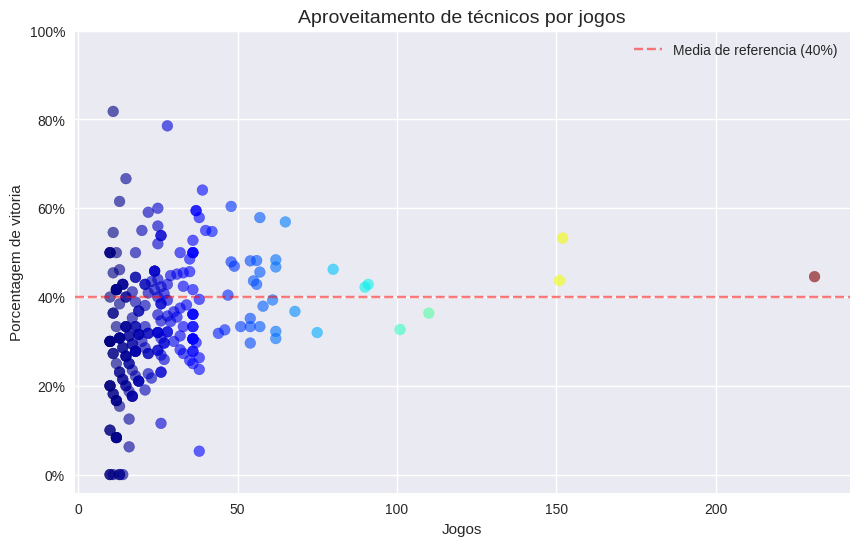

In [14]:
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8')
plt.scatter(df_unificado['jogos'], df_unificado['vitoria'],
            c=df_unificado['jogos'],
            cmap='jet',
            alpha=0.6,
            s=60
            )
plt.axhline(y=0.4, color='red', linestyle='--', alpha=0.5, label='Media de referencia (40%)')
plt.legend()
plt.title('Aproveitamento de técnicos por jogos', fontsize=14)
plt.xlabel('Jogos')
plt.ylabel('Porcentagem de vitoria')
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0], ['0%', '20%', '40%', '60%', '80%', '100%'])
plt.show()

<BarContainer object of 5 artists>

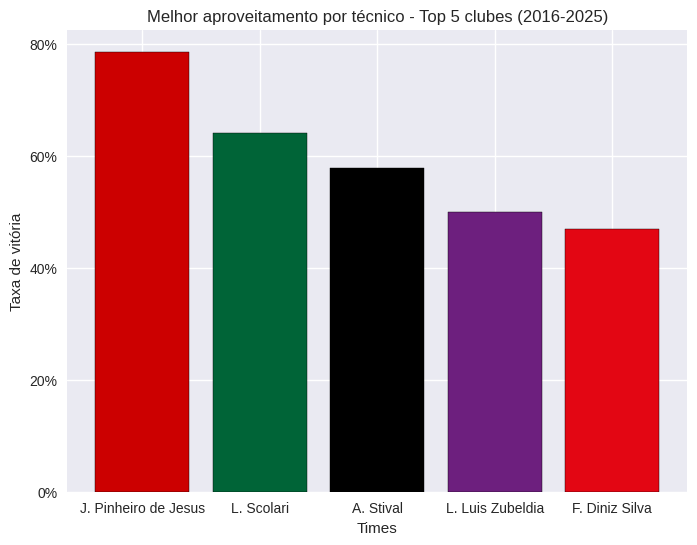

In [15]:
plt.figure(figsize=(8,6))
plt.title('Melhor aproveitamento por técnico - Top 5 clubes (2016-2025)')
plt.xlabel('Times')
plt.ylabel('Taxa de vitória')
plt.yticks([0, 0.2, 0.4, 0.6, 0.8], ['0%', '20%', '40%', '60%', '80%'])

plt.bar(treinador_por_clube['tecnico'], treinador_por_clube['vitoria'],
        color =['#CC0000','#006437', '#000000','#6D1F7E', '#E30613'],
        edgecolor ='black',
        )

### 7. Conclusões

* O dataset filtrado tem **239 combinações** de técnico e clube com
  pelo menos 10 jogos.

* Técnicos com 50 ou mais jogos tem média de aproveitamento de
  41.2%, contra 34.4% da média geral. A permanência no cargo
  está associada a resultados melhores no Brasileirão.

* **Renato Gaúcho no Grêmio** e o caso mais expressivo: **231 jogos**
  com 44.6% de aproveitamento, a maior longevidade do período.
  **Abel Ferreira no Palmeiras** combina volume (152 jogos) com o
  melhor aproveitamento entre os técnicos de longa data, 53.3%.

* O primeiro gráfico confirma o padrão: técnicos com poucos jogos tem
  aproveitamento muito disperso, de 0% a 80%. Conforme o número
  de jogos aumenta, os valores convergem para uma faixa estavel
  entre 35% e 55%, sugerindo que a permanência no cargo estabiliza
  os resultados.

* Já no segundo gráfico, entre os top 5 clubes, **Jorge Jesus no Flamengo** se destaca com a maior
  taxa de vitória: **78.6% em 28 jogos**. Um aproveitamento extraordinário
  que reflete o período mais vitorioso do clube na era moderna.

* **''Felipão'' no Palmeiras** aparece em segundo com **64.1%**, porém com
  volume muito superior: 39 jogos. Combinando consistência e quantidade,
  é o técnico de maior impacto sustentado entre os top 5.

* Os demais clubes ficaram entre 47% e 58%, todos acima da média geral
  do dataset de 34.4%, confirmando que os times mais vencedores do período
  também tiveram os melhores técnicos no comando.